# Notebook Objectives

Study the following:

# Deviation spread
$f(n,\tau)$ a function that should explain the spread of the correlation functions as a function of both $n$ and $\tau$

# g dependence

How the magnetic field $g$ informs the distribution. We should expect that signatures of criticality should be seen.

# $\tau_n$ distribution

Where do the markers that indicate adiabaticity appear for different string lengths? 

In [1]:
import sys
sys.path.append("../../src")
from common_imports import *
from kibble_zurek import *

# $g$ dependence

In [96]:
def Pvar(n,tau):
    L = 256
    t = np.linspace(-10*tau,tau,25)
    DeltaP = np.zeros((len(n),len(t)))
    for i,ti in enumerate(t):
        s = state(L,tau,ti)
        for j,nj in enumerate(n):
            P0 = P_n(nj,s)
            DeltaP[j,i]= P0*(1-P0)
    return t,DeltaP

In [103]:
#t, variance = Pvar([2,10],10)
t2, variance2 = Pvar([2,12],100)


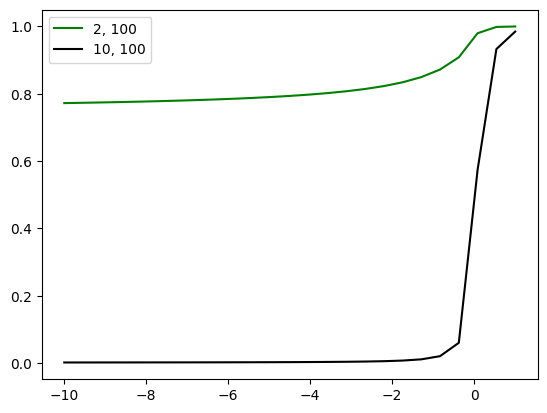

In [104]:
#plot(t/10,(0.25-variance.T[:,1]),color="red",label="10")
plot(t2/100,(variance2.T[:,0])/.25,color="green",label="2, 100")
plot(t2/100,(variance2.T[:,1])/.25,color="black",label="10, 100")
#plot(t/10,0.25-(variance.T[:,0]),color="green",label="2, 10",ls="--")
#plot(t/10,0.25-(variance.T[:,1]),color="black",label="10,100",ls="--")

#yscale("log")
#xlim(.5,1)
#scale("log")
legend()

Compare that to final $\tau$ values only
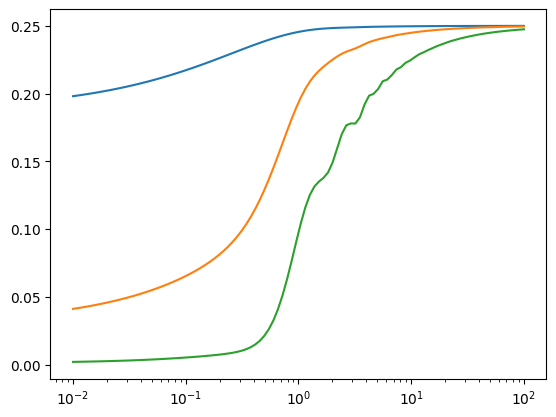

In [ ]:
def Pvar_tau(n,taus,frac):
    ###
    # Calculates variance from final tau values
    ###
    L = 256
    DeltaP = np.zeros((len(n),len(taus)))

    for i, tau in enumerate(taus):
        s=  state(L,tau,tau/frac)
        for j, nj in enumerate(n):
            P0 = P_n(nj,s)
            DeltaP[j,i] = P0*(1-P0)
            
    return DeltaP

taus = np.logspace(-3,3,100)

In [115]:
states = [state(256,tau,tau) for tau in taus]

rho = array([1/2-sigma_general([0,1],s)/2 for s in states])



/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/kibble_zurek.py:44: RuntimeWarning: invalid value encountered in scalar multiply
  return prefactor*complex(pcfd(nu,argument))
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/kibble_zurek.py:60: RuntimeWarning: invalid value encountered in multiply
  return prefactor*complex(pcfd(nu,argument))
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [120]:
data= Pvar_tau([2,6,12],taus,1)
#data2=Pvar_tau([2,10],taus,4)
#data3=Pvar_tau([2,10],taus,1000)

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/kibble_zurek.py:44: RuntimeWarning: invalid value encountered in scalar multiply
  return prefactor*complex(pcfd(nu,argument))
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/fluctuations_of_mean/../../src/kibble_zurek.py:60: RuntimeWarning: invalid value encountered in multiply
  return prefactor*complex(pcfd(nu,argument))
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Text(0, 0.5, 'Variance')

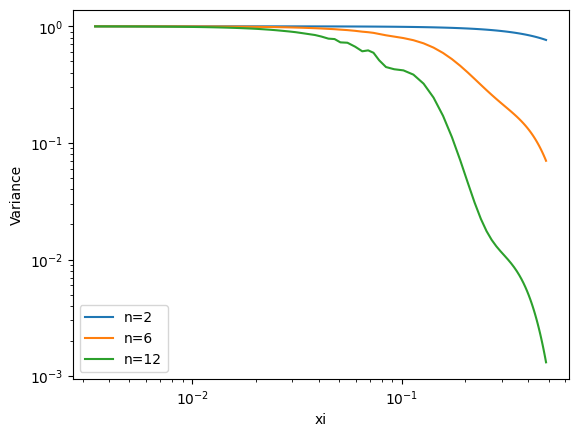

In [121]:
plot(rho,data.T[:,0]/.25,label="n=2")
plot(rho,data.T[:,1]/.25,label="n=6")
plot(rho,data.T[:,2]/.25,label="n=12")

yscale("log")
xscale("log")
legend()
xlabel("xi")
ylabel("Variance")

In [114]:
# plot(taus,data.T)
# xscale("log")

In [134]:
from sympy import Rational, expand
from sympy.physics.secondquant import Fd, F, NO

# fermion operators for sites 1 and 2
c1, c1d = F(1), Fd(1)
c2, c2d = F(2), Fd(2)

# build σx in JW form
sigma1x = -c1 + c1d
sigma2x =  (c2 + c2d)

# projector
P2 = sigma1x*sigma2x

# expand with normal ordering
P2_expanded = ((P2))
print(P2_expanded)


(-AnnihilateFermion(1) + CreateFermion(1))*(AnnihilateFermion(2) + CreateFermion(2))


In [135]:
P2

(-AnnihilateFermion(1) + CreateFermion(1))*(AnnihilateFermion(2) + CreateFermion(2))